# COVID-19 — Clustering Dataset Réel
## Même structure que le notebook 03 — GPU cuML + CPU sklearn

Objectif : découvrir des groupes naturels dans les données réelles sans utiliser les labels.
On interprétera ensuite la composition de chaque cluster pour identifier des profils
(ex. profil symptomatique sévère vs profil exposé sans symptômes marqués).

In [5]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score, davies_bouldin_score, silhouette_samples
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
print('OK')

OK


## 1. Chargement des données

In [6]:
df = pd.read_csv('Covid Dataset.csv')

# Encodage Yes/No -> 1/0
df_enc = df.copy()
for col in df.columns:
    df_enc[col] = (df[col].str.strip() == 'Yes').astype(int)

# Suppression colonnes constantes
constant_cols = [c for c in df_enc.columns if df_enc[c].std() == 0]
print(f'Colonnes constantes supprimées : {constant_cols}')
df_enc = df_enc.drop(columns=constant_cols)

FEATURES = [c for c in df_enc.columns if c != 'COVID-19']
X_full = df_enc[FEATURES].copy()
y_full = df_enc['COVID-19'].copy()

print(f'Shape X : {X_full.shape}')
print(f'COVID+ : {y_full.sum()} ({y_full.mean()*100:.1f}%) | COVID- : {(y_full==0).sum()} ({(y_full==0).mean()*100:.1f}%)')
print(f'Features ({len(FEATURES)}) : {FEATURES}')

Colonnes constantes supprimées : ['Wearing Masks', 'Sanitization from Market']
Shape X : (5434, 18)
COVID+ : 4383 (80.7%) | COVID- : 1051 (19.3%)
Features (18) : ['Breathing Problem', 'Fever', 'Dry Cough', 'Sore throat', 'Running Nose', 'Asthma', 'Chronic Lung Disease', 'Headache', 'Heart Disease', 'Diabetes', 'Hyper Tension', 'Fatigue ', 'Gastrointestinal ', 'Abroad travel', 'Contact with COVID Patient', 'Attended Large Gathering', 'Visited Public Exposed Places', 'Family working in Public Exposed Places']


## 2. Courbe Elbow — GPU cuML

On teste k=2 à k=8 pour identifier le coude d'inertie.

In [7]:
import cupy as cp
import rmm
from cuml.cluster import KMeans as cuKMeans

# Mémoire partagée pour éviter les débordements VRAM
rmm.reinitialize(managed_memory=True)

# Conversion GPU
X_gpu = cp.asarray(X_full.values.astype(np.float32))

inertias = []
K_range = range(2, 9)

print('Computing Elbow Curve (GPU)...')
for k in K_range:
    print(f'k={k} ... ', end='', flush=True)
    km = cuKMeans(n_clusters=k, random_state=42, n_init=5)
    km.fit(X_gpu)
    inertias.append(float(km.inertia_))
    print('✓')

print('\nInertias :', inertias)
diffs = np.diff(inertias)
print('Diffs    :', diffs)

Computing Elbow Curve (GPU)...
k=2 ... ✓
k=3 ... ✓
k=4 ... ✓
k=5 ... ✓
k=6 ... ✓
k=7 ... ✓
k=8 ... ✓

Inertias : [21268.0234375, 20153.375, 19435.2890625, 18873.3125, 18245.1484375, 17967.0234375, 17334.1953125]
Diffs    : [-1114.6484375  -718.0859375  -561.9765625  -628.1640625  -278.125
  -632.828125 ]


## 3. Scores Silhouette — candidats k=2,3,4

On entraîne sur 100% des données (GPU) mais on évalue la silhouette sur un échantillon CPU
(même approche que le notebook 03 — max 20 000 lignes).

In [8]:
import gc

rmm.reinitialize(managed_memory=True)

candidates = [2, 3, 4]
silhouette_scores_dict = {}
X_full_cpu = X_full.values.astype(np.float32)

# Échantillon fixe pour reproductibilité
MAX_SAMPLES = min(20000, len(X_full_cpu))
np.random.seed(42)
idx = np.random.choice(len(X_full_cpu), size=MAX_SAMPLES, replace=False)
X_sample = X_full_cpu[idx]

print(f'Computing Silhouette Scores (training on 100% data, eval on {MAX_SAMPLES} samples)...')
for k in candidates:
    print(f'k={k} ... ', end='', flush=True)
    km = cuKMeans(n_clusters=k, random_state=42, n_init=10)
    labels_full = cp.asnumpy(km.fit_predict(cp.asarray(X_full_cpu)))
    labels_sample = labels_full[idx]
    score = silhouette_score(X_sample, labels_sample)
    silhouette_scores_dict[k] = score
    print(f'Silhouette={score:.4f}')
    gc.collect()

print('\n' + '='*50)
print('RÉSULTATS SILHOUETTE :')
for k, v in silhouette_scores_dict.items():
    print(f'   k={k}: {v:.4f}')
best_k_sil = max(silhouette_scores_dict, key=silhouette_scores_dict.get)
print(f'\nBest k by Silhouette: {best_k_sil}')

Computing Silhouette Scores (training on 100% data, eval on 5434 samples)...
k=2 ... Silhouette=0.0957
k=3 ... Silhouette=0.0775
k=4 ... Silhouette=0.0756

RÉSULTATS SILHOUETTE :
   k=2: 0.0957
   k=3: 0.0775
   k=4: 0.0756

Best k by Silhouette: 2


## 4. Score Davies-Bouldin — k=2 à 8

In [9]:
db_scores = []
print('Computing Davies-Bouldin Scores (GPU)...')
for k in K_range:
    print(f'k={k} ... ', end='', flush=True)
    km = cuKMeans(n_clusters=k, random_state=42, n_init=5)
    labels = cp.asnumpy(km.fit_predict(cp.asarray(X_full_cpu)))
    db = davies_bouldin_score(X_full_cpu, labels)
    db_scores.append(db)
    print(f'DB={db:.3f}')

best_k_db = list(K_range)[np.argmin(db_scores)]
print(f'\nBest k by Davies-Bouldin: {best_k_db}')

Computing Davies-Bouldin Scores (GPU)...
k=2 ... DB=3.457
k=3 ... DB=3.396
k=4 ... DB=3.206
k=5 ... DB=3.038
k=6 ... DB=2.851
k=7 ... DB=2.838
k=8 ... DB=2.645

Best k by Davies-Bouldin: 8


## 5. Visualisation Elbow + Silhouette

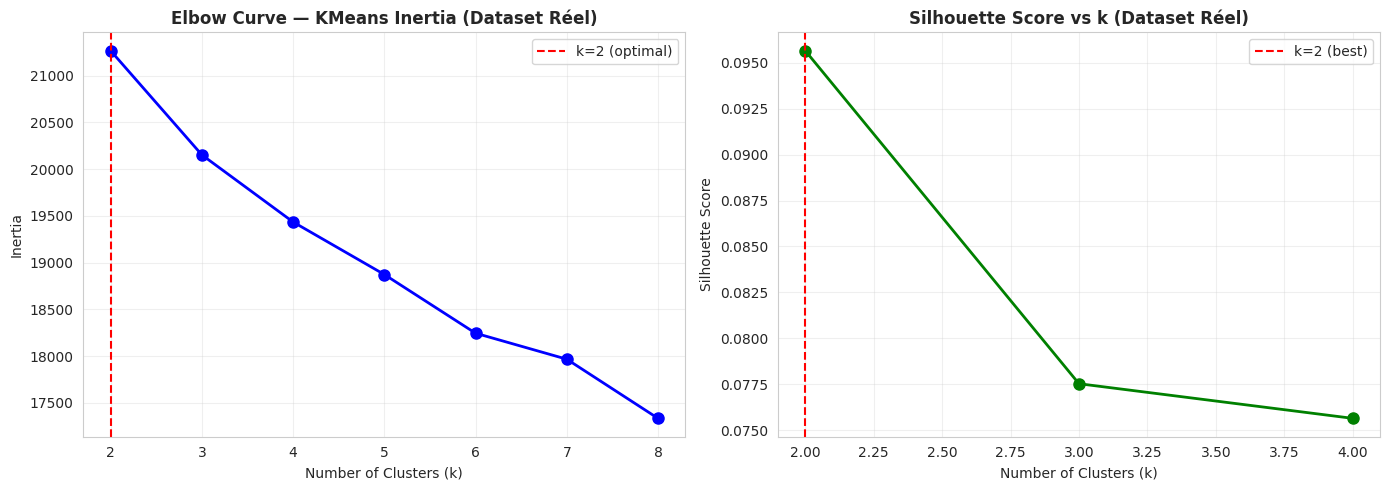

Saved: 05_elbow_silhouette_reel.png


In [10]:
silhouettes_list = [silhouette_scores_dict.get(k, np.nan) for k in K_range]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Curve — KMeans Inertia (Dataset Réel)', fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=best_k_sil, color='r', linestyle='--', label=f'k={best_k_sil} (optimal)')
axes[0].legend()

axes[1].plot(list(K_range), silhouettes_list, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs k (Dataset Réel)', fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].axvline(x=best_k_sil, color='r', linestyle='--', label=f'k={best_k_sil} (best)')
axes[1].legend()

plt.tight_layout()
plt.savefig('05_elbow_silhouette_reel.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: 05_elbow_silhouette_reel.png')

## 6. Décision finale + entraînement du modèle optimal

In [11]:
print('\n' + '='*60)
print('CLUSTERING ANALYSIS SUMMARY')
print('='*60)
for k in candidates:
    db_idx = k - 2
    print(f'k={k}: Silhouette={silhouette_scores_dict.get(k, "N/A"):.4f}, Inertia={inertias[k-2]:.0f}, DB={db_scores[db_idx]:.3f}')

if best_k_sil == best_k_db:
    best_k_final = best_k_sil
    print(f'\n✓ BOTH metrics agree: Use k={best_k_final}')
else:
    best_k_final = best_k_sil  # Silhouette prioritaire
    print(f'\n⚠ Metrics disagree — Silhouette: k={best_k_sil} | DB: k={best_k_db}')
    print(f'→ Decision: k={best_k_final} (Silhouette prioritaire)')

# Entraînement final
kmeans_final = cuKMeans(n_clusters=best_k_final, random_state=42, n_init=10)
labels_final = cp.asnumpy(kmeans_final.fit_predict(cp.asarray(X_full_cpu)))

unique, counts = np.unique(labels_final, return_counts=True)
print(f'\nCluster sizes: {dict(zip(unique, counts))}')


CLUSTERING ANALYSIS SUMMARY
k=2: Silhouette=0.0957, Inertia=21268, DB=3.457
k=3: Silhouette=0.0775, Inertia=20153, DB=3.396
k=4: Silhouette=0.0756, Inertia=19435, DB=3.206

⚠ Metrics disagree — Silhouette: k=2 | DB: k=8
→ Decision: k=2 (Silhouette prioritaire)

Cluster sizes: {np.int32(0): np.int64(1401), np.int32(1): np.int64(4033)}


## 7. Composition des clusters — COVID+ vs COVID-

On analyse ce que contient chaque cluster par rapport aux vrais labels (post-hoc).

In [12]:
y_np = y_full.values

print('\nCluster Composition (COVID labels) :')
purity_scores = []
cluster_profiles = []

for i in range(best_k_final):
    mask = labels_final == i
    n_total   = mask.sum()
    n_covid   = (y_np[mask] == 1).sum()
    n_noncovid = (y_np[mask] == 0).sum()
    purity    = max(n_covid, n_noncovid) / n_total
    purity_scores.append(purity)
    print(f'  Cluster {i}: {n_total} obs | COVID+: {n_covid} ({n_covid/n_total*100:.1f}%) | COVID-: {n_noncovid} ({n_noncovid/n_total*100:.1f}%) | Pureté: {purity*100:.2f}%')
    cluster_profiles.append({'cluster': i, 'total': n_total, 'covid_pos': n_covid, 'covid_neg': n_noncovid, 'purity': purity})

overall_purity = sum(max((y_np[labels_final==i]==1).sum(), (y_np[labels_final==i]==0).sum()) for i in range(best_k_final)) / len(y_np)
print(f'\nPureté globale : {overall_purity*100:.2f}%')
print(f'(Rappel : taux COVID+ dans le dataset = {y_np.mean()*100:.1f}%)')


Cluster Composition (COVID labels) :
  Cluster 0: 1401 obs | COVID+: 415 (29.6%) | COVID-: 986 (70.4%) | Pureté: 70.38%
  Cluster 1: 4033 obs | COVID+: 3968 (98.4%) | COVID-: 65 (1.6%) | Pureté: 98.39%

Pureté globale : 91.17%
(Rappel : taux COVID+ dans le dataset = 80.7%)


## 8. Profil symptomatique moyen par cluster

On compare les moyennes de chaque feature par cluster pour identifier
ce qui caractérise chaque groupe — c'est l'interprétation métier.

In [13]:
X_labeled = X_full.copy()
X_labeled['cluster'] = labels_final
X_labeled['COVID-19'] = y_np

# Moyennes par cluster
cluster_means = X_labeled.groupby('cluster')[FEATURES].mean()
print('=== Moyennes des features par cluster ===')
print(cluster_means.round(3).T.to_string())

# Top features discriminantes entre clusters
diff_clusters = (cluster_means.loc[1] - cluster_means.loc[0]).abs().sort_values(ascending=False)
print('\n=== Top features discriminantes entre clusters ===')
print(diff_clusters.round(4).head(10))

=== Moyennes des features par cluster ===
cluster                                      0      1
Breathing Problem                        0.363  0.771
Fever                                    0.518  0.879
Dry Cough                                0.488  0.898
Sore throat                              0.251  0.893
Running Nose                             0.515  0.553
Asthma                                   0.327  0.510
Chronic Lung Disease                     0.536  0.450
Headache                                 0.530  0.494
Heart Disease                            0.408  0.484
Diabetes                                 0.430  0.492
Hyper Tension                            0.384  0.527
Fatigue                                  0.551  0.508
Gastrointestinal                         0.476  0.467
Abroad travel                            0.066  0.585
Contact with COVID Patient               0.188  0.610
Attended Large Gathering                 0.123  0.580
Visited Public Exposed Places           

## 9. Visualisation — profil des clusters

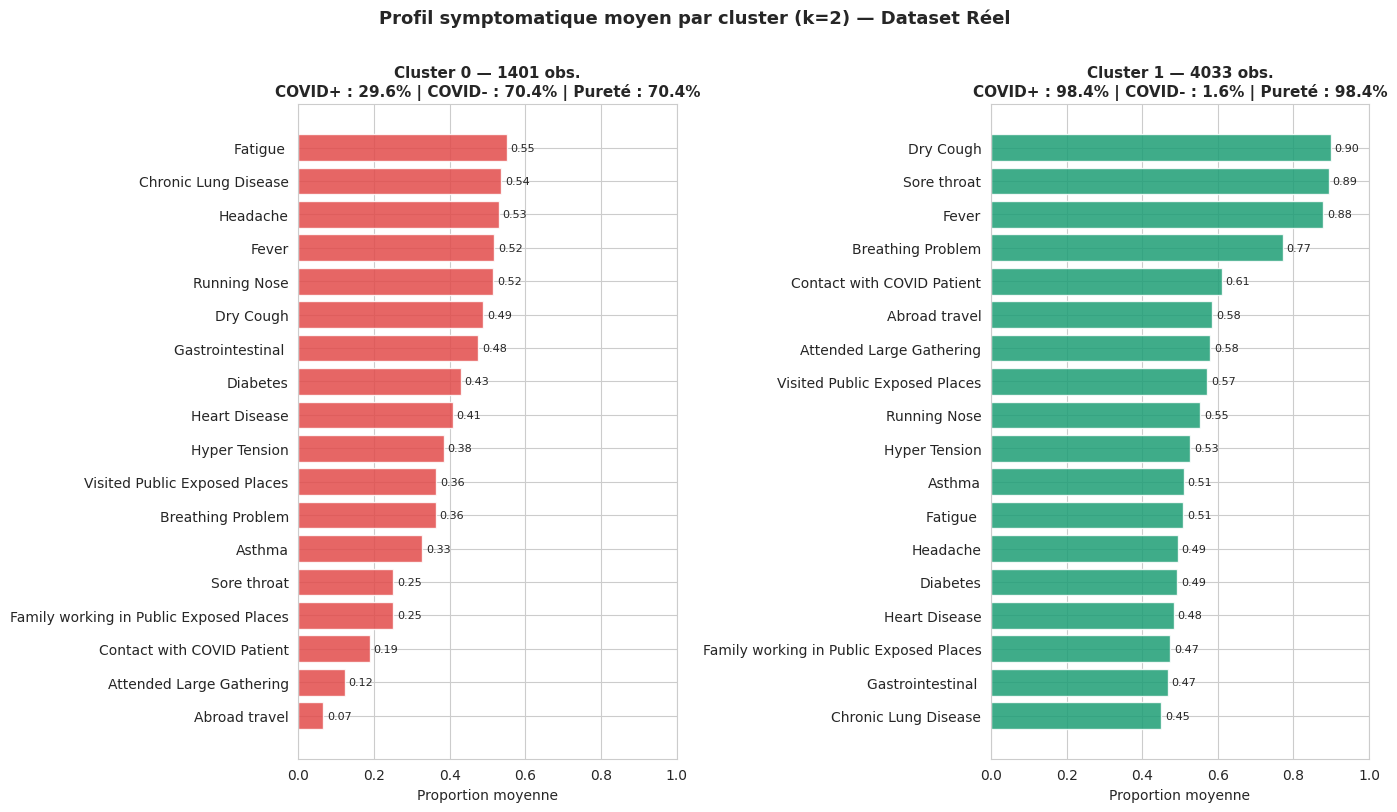

Saved: 05_cluster_profiles_reel.png


In [14]:
colors = ['#E24B4A', '#1D9E75', '#378ADD', '#EF9F27']
labels_names = [f'Cluster {i}' for i in range(best_k_final)]

# Figure 1 : Profil moyen par cluster (barres horizontales)
fig, axes = plt.subplots(1, best_k_final, figsize=(7 * best_k_final, 8))
if best_k_final == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    means = cluster_means.loc[i].sort_values()
    bars = ax.barh(means.index, means.values, color=colors[i], alpha=0.85)
    ax.set_xlim(0, 1)
    info = cluster_profiles[i]
    ax.set_title(
        f'Cluster {i} — {info["total"]} obs.\n'
        f'COVID+ : {info["covid_pos"]/info["total"]*100:.1f}% | '
        f'COVID- : {info["covid_neg"]/info["total"]*100:.1f}% | '
        f'Pureté : {info["purity"]*100:.1f}%',
        fontweight='bold', fontsize=11
    )
    ax.set_xlabel('Proportion moyenne')
    for bar, val in zip(bars, means.values):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center', fontsize=8)

plt.suptitle(f'Profil symptomatique moyen par cluster (k={best_k_final}) — Dataset Réel',
             fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('05_cluster_profiles_reel.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: 05_cluster_profiles_reel.png')

## 10. Silhouette Plot — k optimal

Génération du Silhouette Plot...


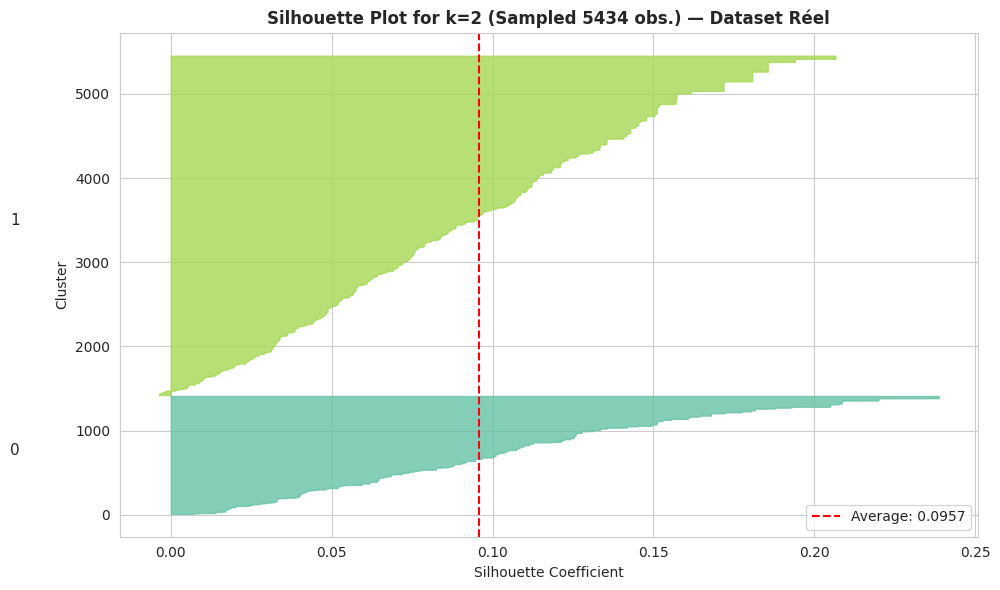

Saved: 05_silhouette_plot_reel.png | Avg silhouette = 0.0957


In [15]:
import matplotlib.cm as cm

print("Génération du Silhouette Plot...")

MAX_PLOT = min(20000, len(X_full_cpu))
np.random.seed(42)
idx_plot = np.random.choice(len(X_full_cpu), size=MAX_PLOT, replace=False)
X_plot   = X_full_cpu[idx_plot]
lbl_plot = labels_final[idx_plot]

sil_vals = silhouette_samples(X_plot, lbl_plot)
sil_avg  = sil_vals.mean()

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10
cmap = cm.get_cmap('Set2')

for i in range(best_k_final):
    vals_i = np.sort(sil_vals[lbl_plot == i])
    size_i = len(vals_i)
    y_upper = y_lower + size_i
    color = cmap(i / best_k_final)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals_i,
                     facecolor=color, edgecolor=color, alpha=0.8)
    ax.text(-0.05, y_lower + size_i / 2, str(i), fontsize=11)
    y_lower = y_upper + 10

ax.axvline(x=sil_avg, color='red', linestyle='--', linewidth=1.5,
           label=f'Average: {sil_avg:.4f}')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.set_title(f'Silhouette Plot for k={best_k_final} (Sampled {MAX_PLOT} obs.) — Dataset Réel',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('05_silhouette_plot_reel.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: 05_silhouette_plot_reel.png | Avg silhouette = {sil_avg:.4f}')

## 11. PCA 2D — visualisation des clusters

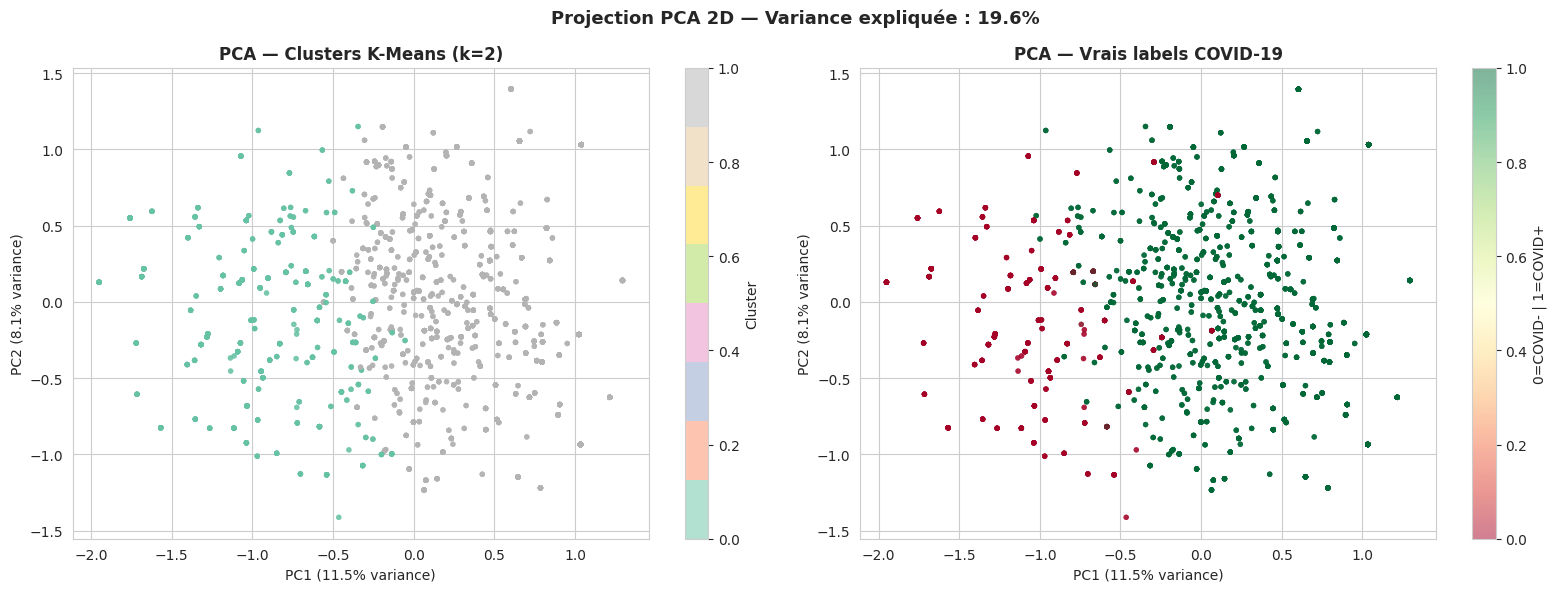

Variance expliquée PC1+PC2 : 19.57%


In [16]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_full_cpu)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Vue par cluster
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_final,
                           cmap='Set2', alpha=0.5, s=15, edgecolors='none')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[0].set_title(f'PCA — Clusters K-Means (k={best_k_final})', fontweight='bold')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Vue par label COVID réel
scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y_np,
                           cmap='RdYlGn', alpha=0.5, s=15, edgecolors='none')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[1].set_title('PCA — Vrais labels COVID-19', fontweight='bold')
plt.colorbar(scatter2, ax=axes[1], label='0=COVID- | 1=COVID+')

plt.suptitle(f'Projection PCA 2D — Variance expliquée : {sum(pca.explained_variance_ratio_[:2]):.1%}',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('05_pca_clusters_reel.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Variance expliquée PC1+PC2 : {sum(pca.explained_variance_ratio_[:2]):.2%}')

## 12. Récapitulatif final + sauvegarde

In [17]:
print('\n' + '='*70)
print('CLUSTERING ANALYSIS SUMMARY — DATASET RÉEL')
print('='*70)
print(f'\nData shape     : {X_full.shape}')
print(f'Features       : {len(FEATURES)}')
print(f'k optimal      : {best_k_final}')
print(f'\nMétriques :')
for k in candidates:
    sil = silhouette_scores_dict.get(k, 'N/A')
    db  = db_scores[k-2]
    marker = ' ← optimal' if k == best_k_final else ''
    print(f'  k={k}: Silhouette={sil:.4f}  Davies-Bouldin={db:.3f}{marker}')

print(f'\nComposition clusters :')
for p in cluster_profiles:
    print(f'  Cluster {p["cluster"]}: {p["total"]} obs | COVID+: {p["covid_pos"]/p["total"]*100:.1f}% | Pureté: {p["purity"]*100:.1f}%')

print(f'\nPureté globale : {overall_purity*100:.2f}%')

# Interprétation automatique des clusters
print('\nInterprétation des clusters :')
for i in range(best_k_final):
    top3 = cluster_means.loc[i].sort_values(ascending=False).head(3)
    bot3 = cluster_means.loc[i].sort_values(ascending=True).head(3)
    p = cluster_profiles[i]
    print(f'  Cluster {i} ({p["total"]} obs, {p["covid_pos"]/p["total"]*100:.0f}% COVID+):')
    print(f'    Features dominantes  : {list(top3.index)}')
    print(f'    Features absentes    : {list(bot3.index)}')

# Sauvegarde
import pickle
clustering_summary = {
    'best_k': best_k_final,
    'silhouette_scores': silhouette_scores_dict,
    'davies_bouldin_scores': db_scores,
    'cluster_labels': labels_final,
    'y_true': y_np,
    'cluster_profiles': cluster_profiles,
    'cluster_means': cluster_means,
    'overall_purity': overall_purity,
    'FEATURES': FEATURES,
}
with open('clustering_reel_summary.pkl', 'wb') as f:
    pickle.dump(clustering_summary, f)
print('\n-> [OK] clustering_reel_summary.pkl')

import joblib
joblib.dump(kmeans_final, 'kmeans_reel_final_model.pkl')
print('-> [OK] kmeans_reel_final_model.pkl')
print('\n✨ CLUSTERING DATASET RÉEL — TERMINÉ')


CLUSTERING ANALYSIS SUMMARY — DATASET RÉEL

Data shape     : (5434, 18)
Features       : 18
k optimal      : 2

Métriques :
  k=2: Silhouette=0.0957  Davies-Bouldin=3.457 ← optimal
  k=3: Silhouette=0.0775  Davies-Bouldin=3.396
  k=4: Silhouette=0.0756  Davies-Bouldin=3.206

Composition clusters :
  Cluster 0: 1401 obs | COVID+: 29.6% | Pureté: 70.4%
  Cluster 1: 4033 obs | COVID+: 98.4% | Pureté: 98.4%

Pureté globale : 91.17%

Interprétation des clusters :
  Cluster 0 (1401 obs, 30% COVID+):
    Features dominantes  : ['Fatigue ', 'Chronic Lung Disease', 'Headache']
    Features absentes    : ['Abroad travel', 'Attended Large Gathering', 'Contact with COVID Patient']
  Cluster 1 (4033 obs, 98% COVID+):
    Features dominantes  : ['Dry Cough', 'Sore throat', 'Fever']
    Features absentes    : ['Chronic Lung Disease', 'Gastrointestinal ', 'Family working in Public Exposed Places']

-> [OK] clustering_reel_summary.pkl
-> [OK] kmeans_reel_final_model.pkl

✨ CLUSTERING DATASET RÉEL — TE